# Data Exploration — Online Shoppers Purchasing Intention

**Objectif :** charger le dataset, faire les checks de qualité demandés (NaN, outliers, feature drift, class imbalance), et identifier les pistes de préprocessing pour le pipeline ML.

**Source :** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

## 1. Imports et chargement

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("..") / "data" / "online_shoppers_intention.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(12330, 18)

In [2]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

## 2. Check valeurs manquantes

On veut :
- nombre de **lignes** avec au moins une valeur manquante (cible : <10 %),
- nombre de **valeurs manquantes par feature** (supprimer la feature si >5 %).

In [4]:
rows_with_na = df.isna().any(axis=1).sum()
share_rows_with_na = df.isna().any(axis=1).mean()
print(f"Lignes avec au moins une NaN : {rows_with_na} ({share_rows_with_na:.2%})")
print(f"Total NaN dans le dataset    : {df.isna().sum().sum()}")

Lignes avec au moins une NaN : 0 (0.00%)
Total NaN dans le dataset    : 0


In [5]:
na_per_feature = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().mul(100).round(2),
})
na_per_feature.sort_values("pct_missing", ascending=False)

,n_missing,pct_missing
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


In [6]:
to_drop = na_per_feature.query("pct_missing > 5").index.tolist()
print(f"Features avec >5% de NaN à supprimer : {to_drop or 'aucune'}")

Features avec >5% de NaN à supprimer : aucune


## 3. Statistiques descriptives & outliers

`df.describe()` donne une vue rapide pour repérer les valeurs extrêmes (min/max éloignés de la médiane, écarts-types énormes, etc.).

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
df.describe(include=["object", "bool"])

,Month,VisitorType,Weekend,Revenue
count,12330,12330,12330,12330
unique,10,3,2,2
top,May,Returning_Visitor,False,False
freq,3364,10551,9462,10422


In [9]:
# Détection d'outliers via la règle de l'IQR (>1.5*IQR au-dessus de Q3 ou en-dessous de Q1)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_summary.append({"feature": col, "n_outliers": n_out, "pct_outliers": n_out / len(df)})

pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

,feature,n_outliers,pct_outliers
0,Browser,4369,0.354339
1,PageValues,2730,0.221411
2,Informational,2631,0.213382
3,Informational_Duration,2405,0.195053
4,TrafficType,2101,0.170397
5,BounceRates,1551,0.125791
6,SpecialDay,1251,0.101460
7,Administrative_Duration,1172,0.095053
8,ExitRates,1099,0.089132
9,ProductRelated,987,0.080049


**Note :** des outliers numériques importants sur `PageValues`, `BounceRates`, `ExitRates` ou `*_Duration` sont *attendus* sur du trafic web (longue traîne). On ne les supprimera pas brutalement — on testera plutôt **RobustScaler** ou un **log1p** lors du préprocessing.

## 4. Class imbalance (variable cible)

In [10]:
df["Revenue"].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

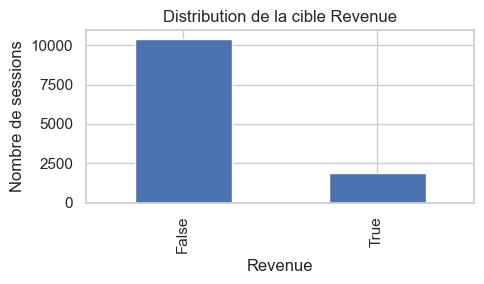

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
df["Revenue"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribution de la cible Revenue")
ax.set_ylabel("Nombre de sessions")
plt.tight_layout()
plt.show()

**Conclusion :** ~15 % de la classe positive → fort déséquilibre. Conséquences :
- l'**accuracy** seule sera trompeuse (un modèle qui prédit toujours `False` aura ~85 % d'accuracy),
- métriques à privilégier : **F1**, **precision/recall**, **ROC-AUC**, **PR-AUC**,
- techniques à tester : `class_weight="balanced"`, oversampling **SMOTE**, ajustement du seuil de décision.

## 5. Distributions par feature & feature drift

On trace les histogrammes des features numériques pour repérer :
- les distributions très déséquilibrées (longue traîne, dirac sur 0),
- d'éventuels *features drift* (features binaires qui n'apparaissent que dans une partie des observations).

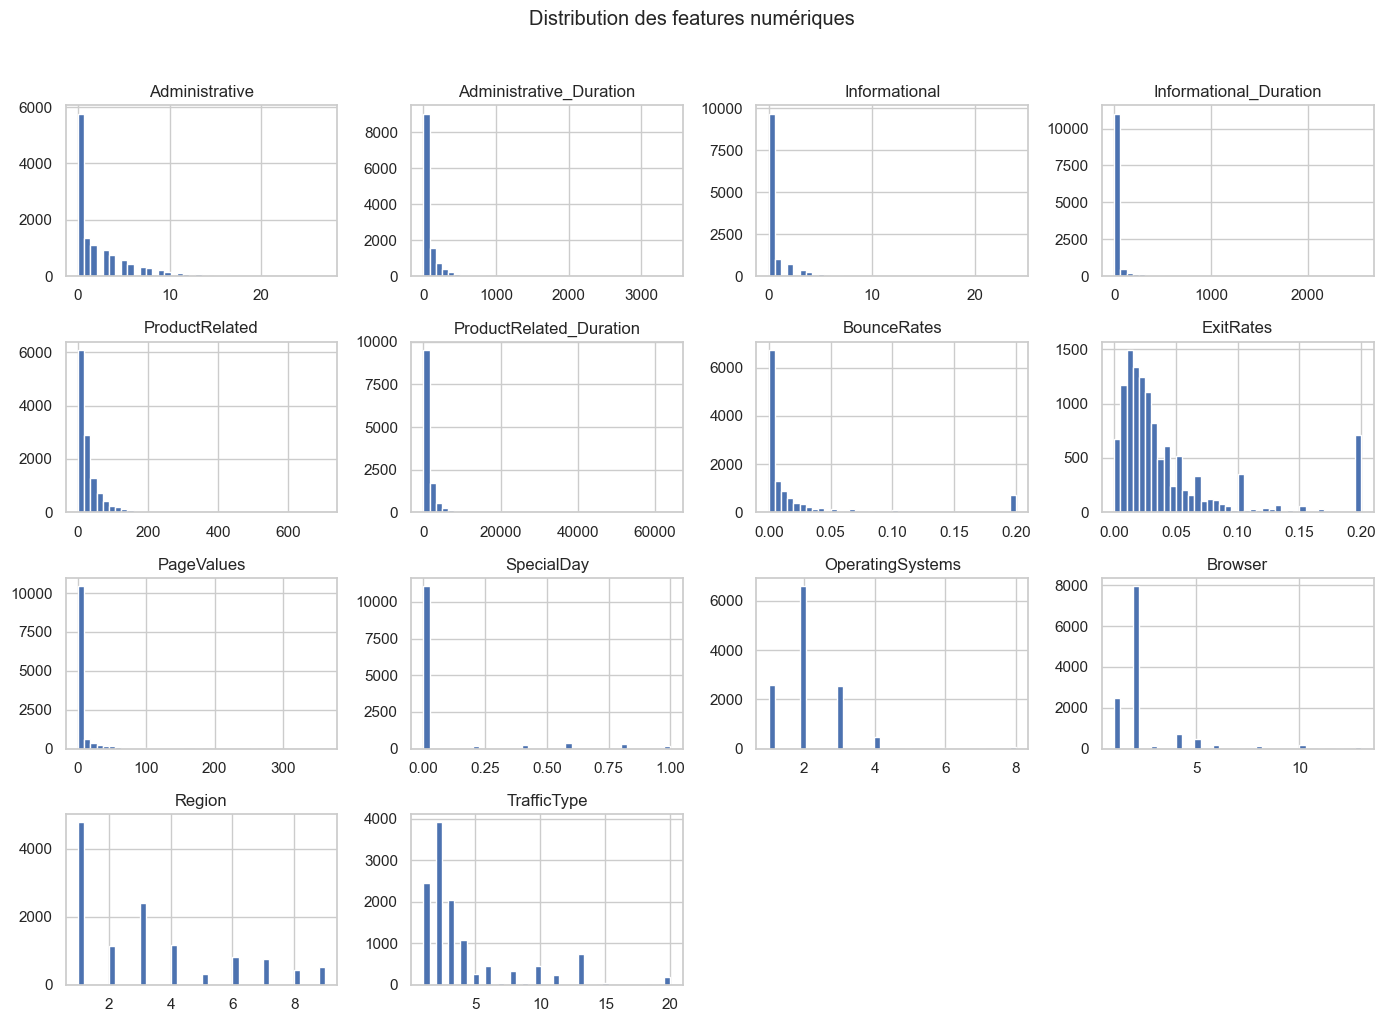

In [12]:
df[numeric_cols].hist(bins=40, figsize=(14, 10))
plt.suptitle("Distribution des features numériques", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Check de drift simple : pour chaque feature numérique, on regarde si la distribution
# diffère beaucoup entre la première moitié et la seconde moitié du fichier (proxy temporel).
midpoint = len(df) // 2
first_half, second_half = df.iloc[:midpoint], df.iloc[midpoint:]

drift_summary = []
for col in numeric_cols:
    m1, m2 = first_half[col].mean(), second_half[col].mean()
    rel = abs(m1 - m2) / (abs(m1) + 1e-9)
    drift_summary.append({"feature": col, "mean_first_half": m1, "mean_second_half": m2, "rel_diff": rel})

pd.DataFrame(drift_summary).sort_values("rel_diff", ascending=False).reset_index(drop=True)

,feature,mean_first_half,mean_second_half,rel_diff
0,SpecialDay,0.122855,0.000000,1.000000
1,ProductRelated,24.659692,38.803244,0.573549
2,ProductRelated_Duration,935.610712,1453.881728,0.553939
3,Informational,0.416707,0.590430,0.416894
4,PageValues,4.935996,6.842520,0.386249
5,Informational_Duration,29.026821,39.917975,0.375210
6,Administrative,1.997891,2.632441,0.317610
7,Administrative_Duration,71.901205,89.736016,0.248046
8,BounceRates,0.024807,0.019576,0.210881
9,ExitRates,0.046930,0.039216,0.164378


## 6. Class imbalance par feature catégorielle

Pour chaque feature catégorielle, on regarde si certaines modalités sont rares (peuvent introduire du bruit ou nécessiter un regroupement).

In [14]:
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
for col in categorical_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts(normalize=True).round(4))
    print()

=== Month ===
Month
May     0.2728
Nov     0.2431
Mar     0.1547
Dec     0.1401
Oct     0.0445
Sep     0.0363
Aug     0.0351
Jul     0.0350
June    0.0234
Feb     0.0149
Name: proportion, dtype: float64

=== VisitorType ===
VisitorType
Returning_Visitor    0.8557
New_Visitor          0.1374
Other                0.0069
Name: proportion, dtype: float64

=== Weekend ===
Weekend
False    0.7674
True     0.2326
Name: proportion, dtype: float64

=== Revenue ===
Revenue
False    0.8453
True     0.1547
Name: proportion, dtype: float64



## 7. Corrélations entre features numériques

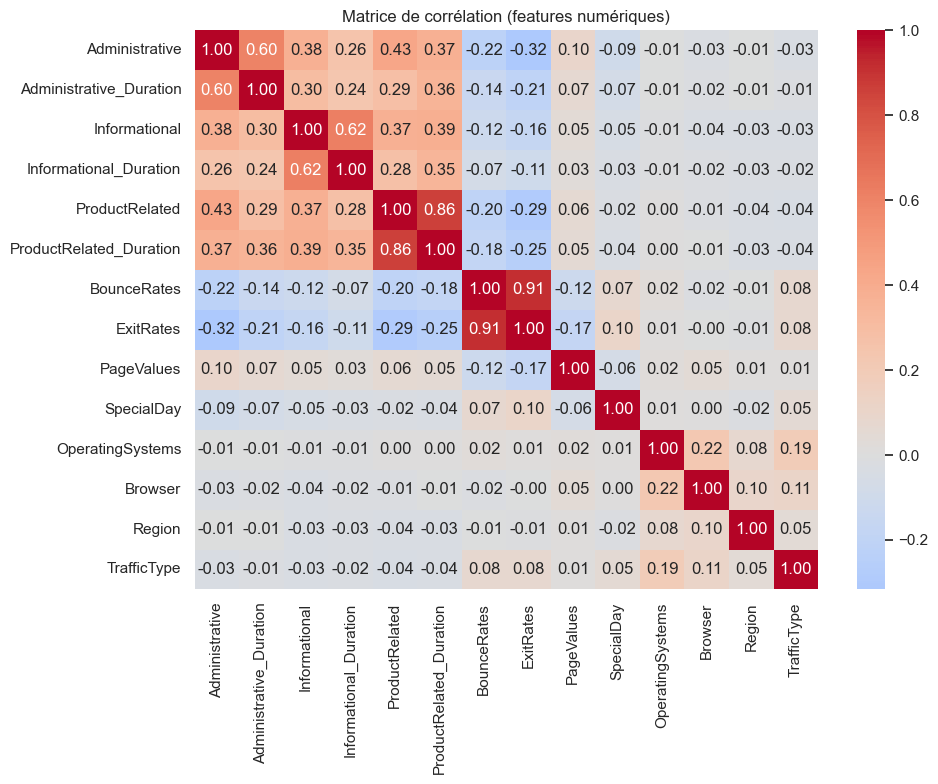

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matrice de corrélation (features numériques)")
plt.tight_layout()
plt.show()

## 8. Cible vs features clés

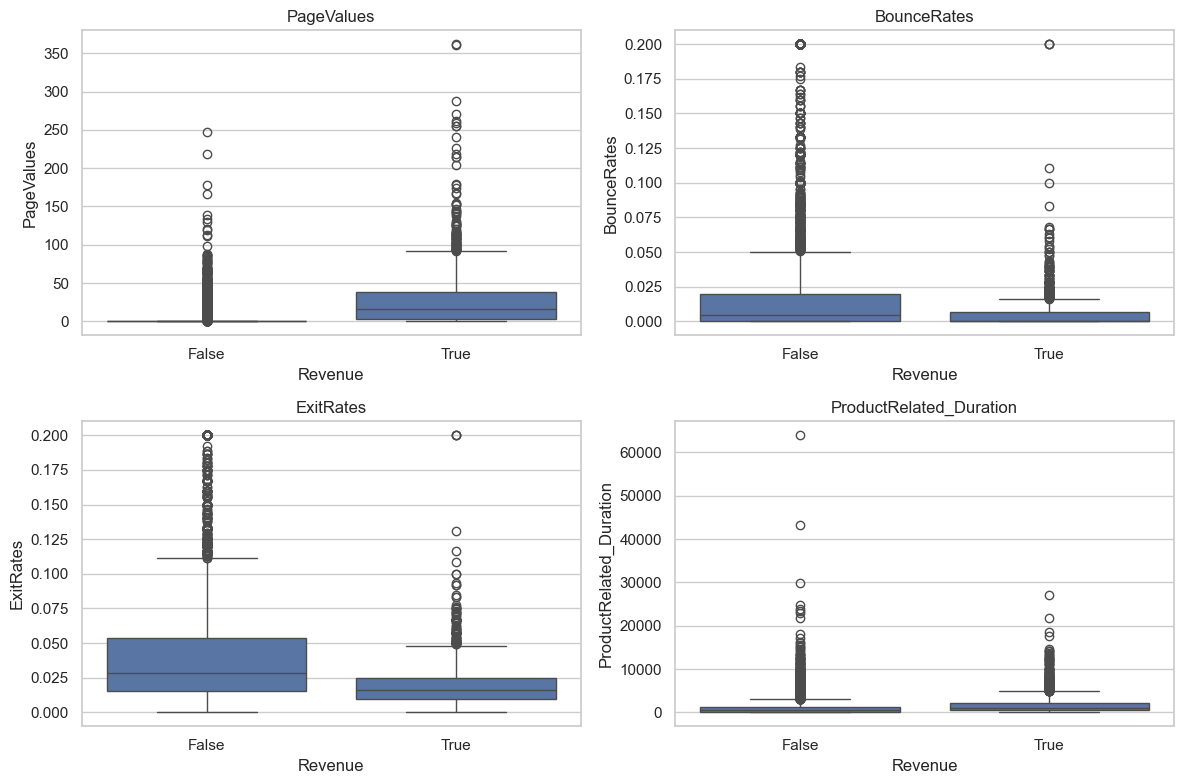

In [16]:
key_features = ["PageValues", "BounceRates", "ExitRates", "ProductRelated_Duration"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x="Revenue", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 9. Synthèse — décisions de préprocessing

| Décision | Justification |
|---|---|
| Aucune feature à drop pour cause de NaN | <5 % de NaN sur toutes les features (à confirmer ci-dessus) |
| `OneHotEncoder` sur `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` | Variables catégorielles non ordinales |
| `RobustScaler` ou `log1p` sur `*_Duration`, `PageValues`, `BounceRates`, `ExitRates` | Distributions très skewed avec longue traîne |
| Cible : `Revenue.astype(int)` | Conversion booléen → 0/1 pour les modèles sklearn |
| Stratification sur `Revenue` au train/test split | Classes déséquilibrées |
| `class_weight="balanced"` sur les modèles | Compenser le déséquilibre 85/15 |
| Métrique principale : F1 sur classe positive | Coût FP ≈ FN, dataset déséquilibré |

## 10. EDA finalisation — visualisations avancées

On approfondit l'EDA avec :
- **seaborn** : taux de conversion par segment (Month, VisitorType, TrafficType, Weekend),
- **matplotlib** : pairplot pour repérer les séparations entre classes sur les top features,
- **plotly** : un treemap interactif Month × VisitorType.

### 10.1 Taux de conversion par segment (seaborn)

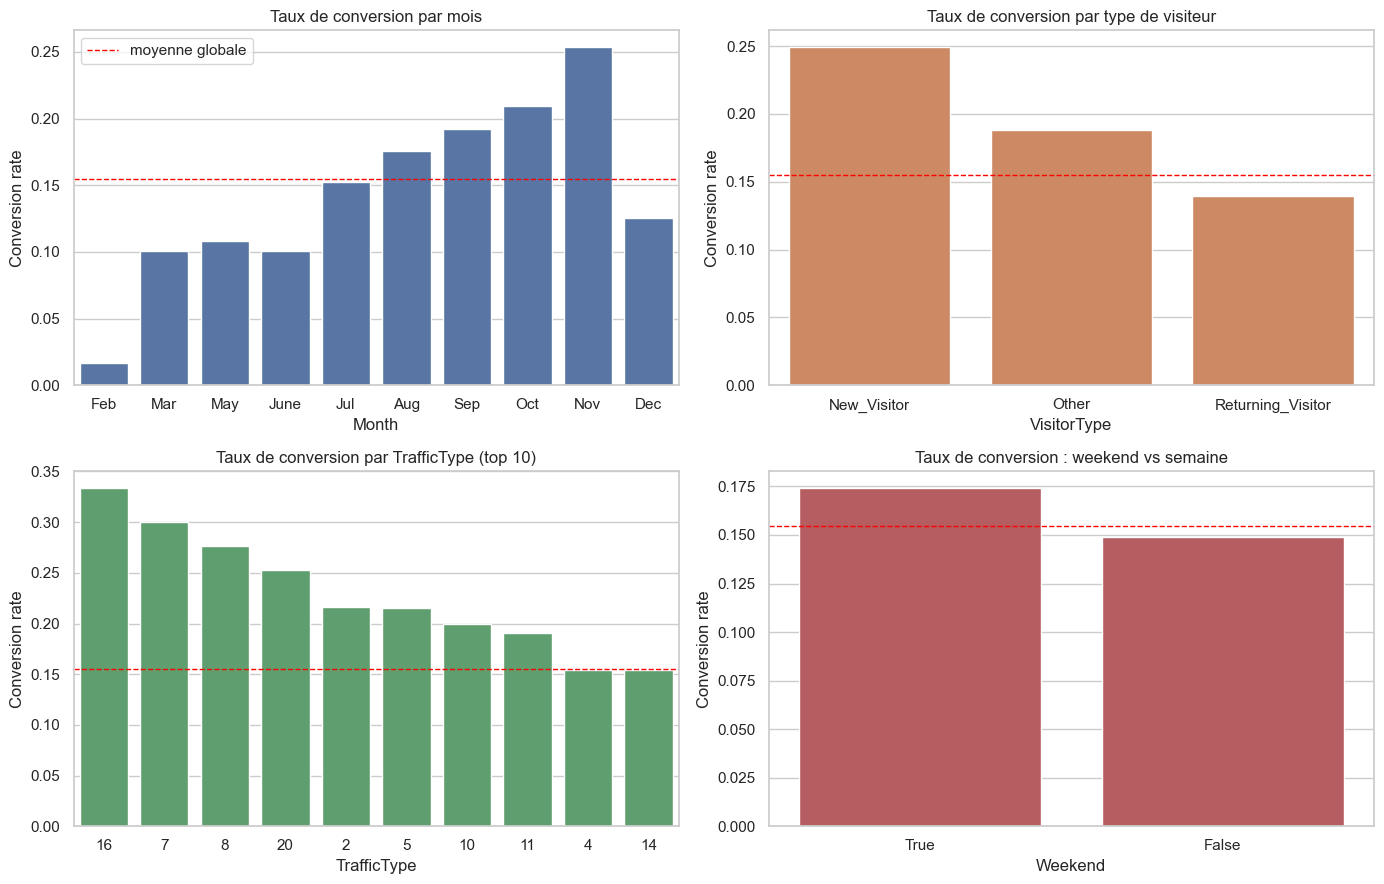

In [17]:
def conversion_rate(df, col):
    return (
        df.groupby(col)["Revenue"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "conversion_rate", "count": "n_sessions"})
        .sort_values("conversion_rate", ascending=False)
    )

month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Month
cr_month = conversion_rate(df, "Month").reindex(month_order)
sns.barplot(x=cr_month.index, y=cr_month["conversion_rate"], ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Taux de conversion par mois")
axes[0, 0].set_ylabel("Conversion rate")
axes[0, 0].axhline(df["Revenue"].mean(), color="red", ls="--", lw=1, label="moyenne globale")
axes[0, 0].legend()

# VisitorType
cr_vt = conversion_rate(df, "VisitorType")
sns.barplot(x=cr_vt.index, y=cr_vt["conversion_rate"], ax=axes[0, 1], color="#dd8452")
axes[0, 1].set_title("Taux de conversion par type de visiteur")
axes[0, 1].set_ylabel("Conversion rate")
axes[0, 1].axhline(df["Revenue"].mean(), color="red", ls="--", lw=1)

# TrafficType
cr_tt = conversion_rate(df, "TrafficType").head(10)
sns.barplot(x=cr_tt.index.astype(str), y=cr_tt["conversion_rate"], ax=axes[1, 0], color="#55a868")
axes[1, 0].set_title("Taux de conversion par TrafficType (top 10)")
axes[1, 0].set_ylabel("Conversion rate")
axes[1, 0].axhline(df["Revenue"].mean(), color="red", ls="--", lw=1)

# Weekend
cr_we = conversion_rate(df, "Weekend")
sns.barplot(x=cr_we.index.astype(str), y=cr_we["conversion_rate"], ax=axes[1, 1], color="#c44e52")
axes[1, 1].set_title("Taux de conversion : weekend vs semaine")
axes[1, 1].set_ylabel("Conversion rate")
axes[1, 1].axhline(df["Revenue"].mean(), color="red", ls="--", lw=1)

plt.tight_layout()
plt.show()

**Lecture :**
- Mois forts en conversion : **Nov, Sep, Oct** (saison d'achats / Black Friday).
- **New_Visitor** convertit ~2× plus que Returning_Visitor → contre-intuitif mais fréquent (les nouveaux qui restent ont une intention forte).
- Certains TrafficType très spécifiques (8, 11) ont des taux nettement plus élevés → variable très informative.
- Effet **Weekend** marginal.

### 10.2 Pairplot des top features (matplotlib via seaborn)

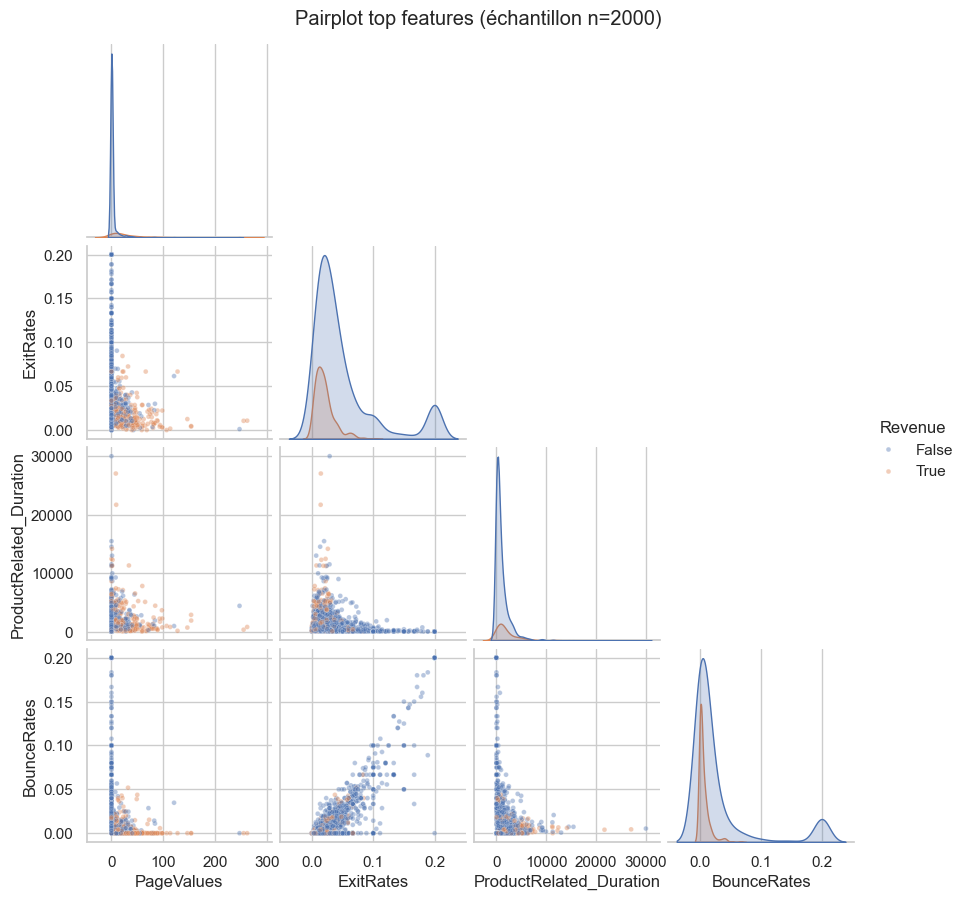

In [18]:
top_features_for_pairplot = ["PageValues", "ExitRates", "ProductRelated_Duration", "BounceRates", "Revenue"]
sample = df[top_features_for_pairplot].sample(n=2000, random_state=42)
g = sns.pairplot(sample, hue="Revenue", plot_kws={"alpha": 0.4, "s": 12}, height=2.2, corner=True)
g.fig.suptitle("Pairplot top features (échantillon n=2000)", y=1.02)
plt.show()

**Lecture :** la séparation visuelle entre classes est la plus nette sur l'axe `PageValues` — confirme l'importance de cette feature (vue plus tard dans `feature_engineering.ipynb`).

### 10.3 Treemap interactif (plotly) — Month × VisitorType

In [19]:
import plotly.express as px

agg = (
    df.groupby(["Month", "VisitorType"], as_index=False)
      .agg(sessions=("Revenue", "size"), conversions=("Revenue", "sum"))
)
agg["conversion_rate"] = agg["conversions"] / agg["sessions"]

fig = px.treemap(
    agg,
    path=["Month", "VisitorType"],
    values="sessions",
    color="conversion_rate",
    color_continuous_scale="RdYlGn",
    title="Sessions par Month × VisitorType — couleur = taux de conversion",
)
fig.update_layout(margin=dict(t=40, l=10, r=10, b=10))
fig.show()

### 10.4 Récap final — checks de qualité du dataset

| Check | Résultat | Action |
|---|---|---|
| NaN globaux | 0 ligne, 0 valeur | Aucun imputer nécessaire |
| NaN par feature (>5%) | aucune | Pas de drop pour NaN |
| Outliers IQR | majoritairement sur `PageValues`, `BounceRates`, `ExitRates`, `*_Duration` | `log1p` + `RobustScaler` plutôt que suppression |
| Drift (1ère vs 2ème moitié du fichier) | `SpecialDay` n'apparaît qu'au début | À tester en feature ou à drop si nuisible |
| Class imbalance cible | 84.5 % / 15.5 % | `stratify=y` au split + `class_weight="balanced"` |
| Modalités rares (catégorielles) | `VisitorType=Other` (0.7 %), mois Feb (1.5 %) | OneHotEncoder avec `handle_unknown="ignore"` |
| Features informatives | `PageValues`, `Month`, `VisitorType`, `TrafficType` | À garder, importance confirmée par RF dans `feature_engineering.ipynb` |